# Finetunning de Stable Diffusion para Portadas de Libros Antiguos
## Máster en Inteligencia Artificial, Cloud Computing y DevOps
## Módulo: Generacion de Imagenes con AI
## Autor: Alexander De Sousa

Este notebook documenta el proceso completo de finetuning de un modelo de difusión (Stable Diffusion 1.5) utilizando un dataset de ilustraciones y portadas de libros antiguos.  
El objetivo es adaptar el modelo base para que aprenda el estilo visual característico de este tipo de obras, generando imágenes coherentes, estilizadas y reproducibles.

El trabajo incluye:

- Preparación y preprocesamiento del dataset.
- Entrenamiento completo del modelo (UNet) y entrenamiento mediante LoRA.
- Comparación entre resultados antes y después del finetuning.
- Evaluación cualitativa del estilo aprendido.
- Publicación del modelo en Hugging Face para su reutilización.

Este documento constituye la entrega final del módulo de Generación de Imágenes con IA.
---


#### 1. Instalación de dependencias
Instalamos las librerías necesarias para trabajar con Stable Diffusion, datasets y entrenamiento acelerado.

In [1]:
!pip install -q "diffusers[torch]" "datasets>=2.16,<2.17" accelerate transformers pillow huggingface_hub


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


#### 2. Imports
Cargamos todas las clases y funciones que vamos a usar en el proyecto.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

from datasets import load_dataset
from diffusers import (
    UNet2DConditionModel,
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionPipeline,
)
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator
from huggingface_hub import upload_folder

#### 3. Configuración de dispositivo
Detectamos si hay GPU disponible en el equipo, en caso de que no exista se entrenara Stable Diffusion con la CPU, pero es extremadamente lento.

In [4]:
device = "cpu"
print("Dispositivo forzado:", device)

Dispositivo forzado: cpu


*Información detallada de la GPU a usar*

#### 4. Cargar dataset nuevo
Cargamos el dataset gigant/oldbookillustrations, que contiene ilustraciones antiguas de libros.

In [5]:
# Nombre del modelo base (Stable Diffusion 1.4)
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Dataset de ilustraciones de libros antiguos
dataset_name = "gigant/oldbookillustrations"

# Limitamos el número de muestras para que el entrenamiento no dure 6+ horas
max_train_samples = 200

dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))

print("Ejemplo de claves del dataset:", dataset[0].keys())

Ejemplo de claves del dataset: dict_keys(['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url'])


#### Visualizamos portadas en miniatura

In [6]:
dataset.features

{'rawscan': Image(decode=True, id=None),
 '1600px': Image(decode=True, id=None),
 'info_url': Value(dtype='string', id=None),
 'info_src': Value(dtype='string', id=None),
 'info_alt': Value(dtype='string', id=None),
 'artist_name': Value(dtype='string', id=None),
 'artist_birth_date': Value(dtype='string', id=None),
 'artist_death_date': Value(dtype='string', id=None),
 'artist_countries': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'book_title': Value(dtype='string', id=None),
 'book_authors': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'book_publishers': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'date_published': Value(dtype='string', id=None),
 'openlibrary-url': Value(dtype='string', id=None),
 'tags': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'illustration_source_name': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'illustration_source_url': Sequ

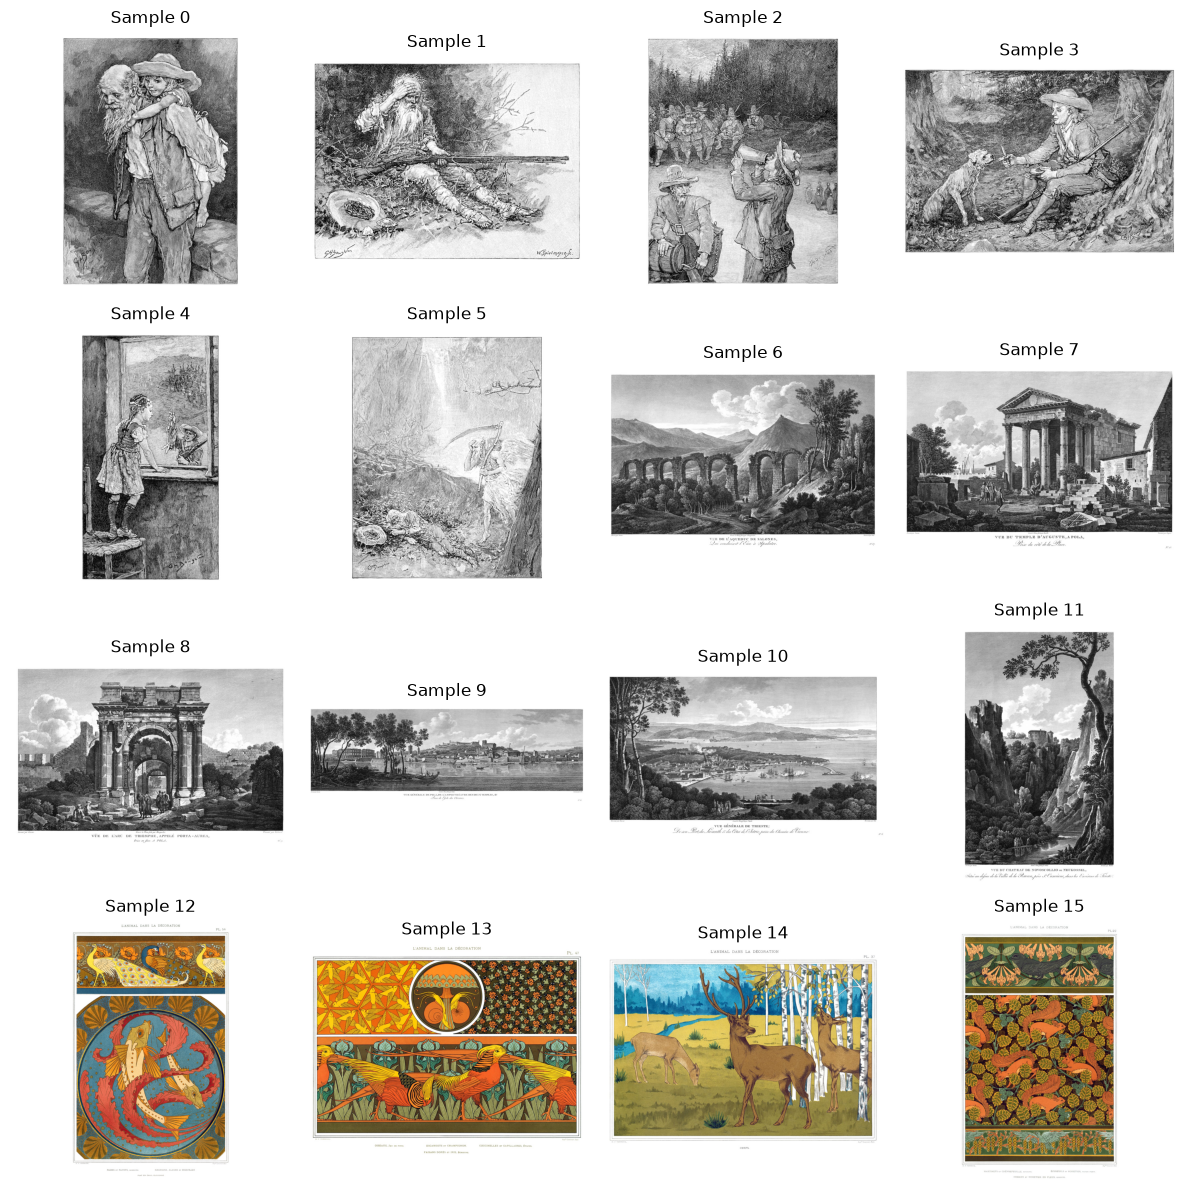

In [7]:
# Visualización de 9 portadas del dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
for i in range(16):
    img = dataset[i]["1600px"]
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(f"Sample {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 5. Transformaciones (imágenes no cuadradas)
Convertimos las imágenes a un formato que Stable Diffusion pueda usar.

In [8]:
resolution = 512

image_transforms = transforms.Compose([
    transforms.Resize(resolution),
    transforms.CenterCrop((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


#### 6. Tokenizer
Cargamos el tokenizer de CLIP, que convierte texto en tokens numéricos.

In [9]:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder="tokenizer")

#### 7. Dataset wrapper adaptado


In [10]:
class OldBookDataset(Dataset):
    """
    Dataset para el finetuning:
    - Usa la columna '1600px' como imagen
    - Usa la columna 'info_alt' como descripción
    - Convierte todas las imágenes a RGB (aunque algunas sean B/N)
    """

    def __init__(self, hf_dataset, tokenizer, image_transforms):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]

        # Imagen: columna '1600px', convertida a RGB
        image: Image.Image = example["1600px"].convert("RGB")
        image = self.image_transforms(image)

        # Texto: columna 'info_alt'
        text = example["info_alt"]

        tokens = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids.squeeze(0),
            "attention_mask": tokens.attention_mask.squeeze(0),
        }

train_dataset = OldBookDataset(dataset, tokenizer, image_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
len(train_dataset), next(iter(train_dataloader))["pixel_values"].shape


(200, torch.Size([2, 3, 512, 512]))

#### 8. Cargar componentes del modelo base

In [11]:
# Scheduler de difusión
noise_scheduler = DDPMScheduler.from_pretrained(
    pretrained_model_name,
    subfolder="scheduler"
)

# Text encoder CLIP (CPU + float32)
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
    torch_dtype=torch.float32
).to("cpu")

# VAE (Autoencoder) (CPU + float32)
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
    torch_dtype=torch.float32
).to("cpu")

# UNet (CPU + float32)
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
    torch_dtype=torch.float32
).to("cpu")


/home/alexd/GitHub/SinGPU/env-SinGPU/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

#### 9. Congelar VAE y Text Encoder (Transfer learning)
No queremos entrenar VAE ni text encoder, solo la UNet

In [12]:
vae.eval()
text_encoder.eval()

for p in vae.parameters():
    p.requires_grad = False

for p in text_encoder.parameters():
    p.requires_grad = False

#### 10. Preparar entrenamiento
En este caso el num_epochs lo ajustamos a 2, tal cual como lo sugiere el enunciado del ejercicio.

In [13]:
learning_rate = 1e-5
num_epochs = 2

# Optimizador
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Accelerator forzado a CPU
accelerator = Accelerator(
    cpu=True,                   # ← OBLIGATORIO
    mixed_precision="no",
    gradient_accumulation_steps=1
)

# Preparamos UNet, optimizer y dataloader para CPU
unet, optimizer, train_dataloader = accelerator.prepare(
    unet, optimizer, train_dataloader
)

print("⚙️   Accelerator device:", accelerator.device)
print("🚀  Accelerator mixed precision:", accelerator.state.mixed_precision)

# Verificamos que los tensores están en CPU
sample_batch = next(iter(train_dataloader))
print("🔎  pixel_values device:", sample_batch["pixel_values"].device)
print("🔎  input_ids device:", sample_batch["input_ids"].device)


⚙️   Accelerator device: cpu
🚀  Accelerator mixed precision: no
🔎  pixel_values device: cpu
🔎  input_ids device: cpu


#### 11. Bucle de entrenamiento (finetuning)
En esta seccion la UNet aprende a generar imágenes del estilo del dataset.

In [14]:
# 11. Bucle de entrenamiento (versión CPU)

unet.train()

for epoch in range(num_epochs):
    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        leave=True,
    )

    for batch in progress_bar:
        # 1. Encode images → latents (sin gradientes)
        
        with torch.no_grad():
            pixel_values = batch["pixel_values"]  # ya están en CPU y float32

            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215

        
        # 2. Añadir ruido a los latentes
        
        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device="cpu",
        ).long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        
        # 3. Codificar texto
        
        input_ids = batch["input_ids"]  # ya están en CPU
        encoder_hidden_states = text_encoder(input_ids)[0]

        
        # 4. Predicción del ruido por la UNet
        
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        
        # 5. Cálculo de la pérdida (MSE)
        
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        
        # 6. Back‑prop + actualización del optimizador
        
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())


Epoch 1/2:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/2: 100%|██████████| 100/100 [52:58<00:00, 31.79s/it, loss=0.00671]


#### 12. Guardar el modelo UNet finetuneado
Guardamos la UNet finetuneada en una carpeta de nuestro equipo.

In [15]:
save_path = "./sd-oldbook-finetuned-unet-512-200"
os.makedirs(save_path, exist_ok=True)

unet.save_pretrained(save_path)
print("UNet finetuneada guardada en:", save_path)

UNet finetuneada guardada en: ./sd-oldbook-finetuned-unet-512-200


#### 13. Cuantización ligera para inferencia (FP16)
Nota: esto es para uso en inferencia, no reentrenes en FP16 si tu entorno no está preparado.

In [16]:
# Cargar la UNet finetuneada en float32 (CPU)
unet_cpu = UNet2DConditionModel.from_pretrained(
    save_path,
    torch_dtype=torch.float32
).to("cpu")

# Cargar el pipeline completo en CPU
pipe_finetuned = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=unet_cpu,
    torch_dtype=torch.float32
).to("cpu")

print("Pipeline finetuneado cargado en CPU (float32).")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline finetuneado cargado en CPU (float32).


#### 14. Subir la UNet finuteado a Hugging Face
Subimos la carpeta del modelo finetuneado a nuestro repositorio personal, ubicado en *https://huggingface.co/*

In [17]:
repo_id = "alexdesousa/sd-oldbook-finetuned-512-200"

upload_folder(
    folder_path=save_path,
    repo_id=repo_id,
    repo_type="model"
)

print("Modelo UNet finetuneado subido correctamente a Hugging Face:", repo_id)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo UNet finetuneado subido correctamente a Hugging Face: alexdesousa/sd-oldbook-finetuned-512-200


#### 15. Generar imágenes antes/después

***Antes del finetuning:***  
Generamos una imagen con el modelo original.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

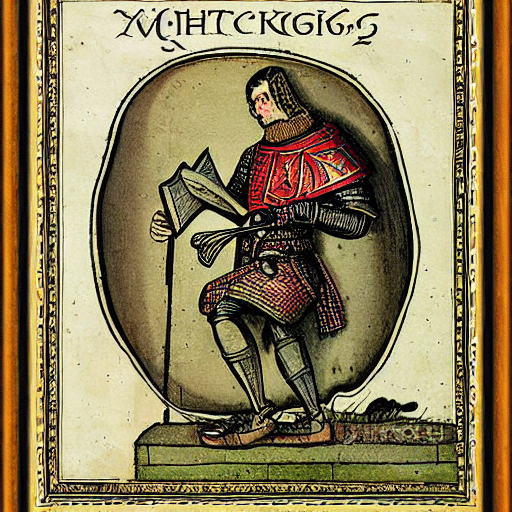

In [28]:
# Cargar el modelo base en CPU (float32)
pipe_base = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    torch_dtype=torch.float32
).to("cpu")

prompt = "an antique book cover depicting a medieval knight reading a book, ornate frame, engraved illustration, vintage ink texture"

# Generar imagen con el modelo original
image_before = pipe_base(prompt).images[0]
image_before.save("modelo_Original-05-512-200.png")

image_before



***Después del finetuning:***  
Generamos la misma imagen con el modelo finetuneado.

  0%|          | 0/50 [00:00<?, ?it/s]

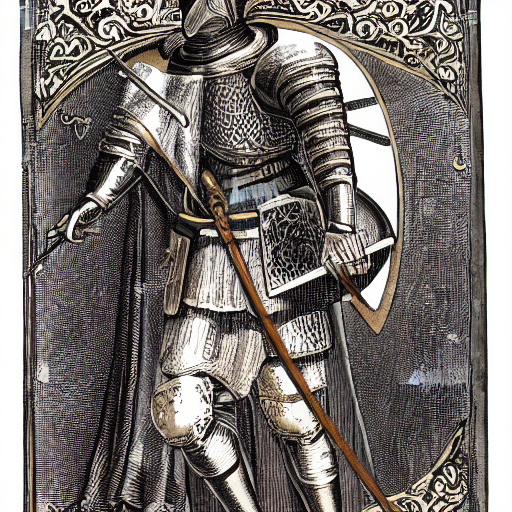

In [29]:
image_after = pipe_finetuned(prompt).images[0]
image_after.save("modelo_Modificado-05-512-200.png")
image_after